In [2]:
# --- 1.librerías ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
%matplotlib qt

ModuleNotFoundError: No module named 'pandas'

In [2]:
# --- 2. Leer el archivo .log ---

## ARCHIVO
#file_path = "C:/Users/sofip/Blade/pruebas_gorra_miercoles_19_11/prueba_2_chris" #mie 19/11

file_path = "C:/Users/sofip/Blade/pruebas_gorra_miercoles_19_11/registro_1_chris.log"

### para el registro del vie 28/11

In [52]:
df = pd.read_csv(file_path, header=None,  names=["force", "timestamp"])
mask_marcas = df["force"].astype(str).str.contains("marca", case=False, na=False)
df_marcas = df[mask_marcas].copy()
df_datos  = df[~mask_marcas].copy()

#print(df_datos)

# Indices donde hay marca
marcas_idx = df_marcas.index

# Para cada marca → tomar el timestamp de la fila anterior
df_marcas["timestamp_idx_ant"] = marcas_idx.map(lambda i: df.loc[i-1, "timestamp"])
df_marcas["force_ant"] = marcas_idx.map(lambda i: df.loc[i-1, "force"])
# filtro marcas iniciales
df_iniciales = df_marcas[df_marcas["force"].str.contains("inicial", case=False, na=False)]

#paso a numeric para poder graficar
df_iniciales["force_ant"] = pd.to_numeric(df_iniciales["force_ant"], errors="coerce")
df_iniciales["timestamp_idx_ant"] = pd.to_numeric(df_iniciales["timestamp_idx_ant"], errors="coerce")

df_datos["force"] = pd.to_numeric(df_datos["force"], errors="coerce")
df_datos["timestamp"] = pd.to_numeric(df_datos["timestamp"], errors="coerce")
print(len(df_iniciales))
print(df_iniciales)



40
               force  timestamp  timestamp_idx_ant  force_ant
6828   marca inicial        NaN       6.850132e+08     0.0054
7146   marca inicial        NaN       6.951676e+08     0.0058
7535   marca inicial        NaN       7.055238e+08     0.0146
7880   marca inicial        NaN       7.151124e+08     0.0087
8220   marca inicial        NaN       7.237238e+08     0.0123
8582   marca inicial        NaN       7.331238e+08     0.0105
8925   marca inicial        NaN       7.416238e+08     0.0155
9299   marca inicial        NaN       7.517260e+08     0.0114
9703   marca inicial        NaN       7.622238e+08     0.0105
10057  marca inicial        NaN       7.708238e+08     0.0078
10451  marca inicial        NaN       7.810379e+08     0.0136
10811  marca inicial        NaN       7.900269e+08     0.0065
11163  marca inicial        NaN       7.996251e+08     0.0076
11545  marca inicial        NaN       8.088238e+08     0.0068
11922  marca inicial        NaN       8.188238e+08     0.0086
12259

C:\Users\sofip\AppData\Local\Temp\ipykernel_2024\1283938694.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_iniciales["force_ant"] = pd.to_numeric(df_iniciales["force_ant"], errors="coerce")
C:\Users\sofip\AppData\Local\Temp\ipykernel_2024\1283938694.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_iniciales["timestamp_idx_ant"] = pd.to_numeric(df_iniciales["timestamp_idx_ant"], errors="coerce")


In [68]:
len(df_datos["time_s"])

21112

In [69]:

plt.figure()
plt.plot(df_datos['timestamp']/1e6,df_datos['force'])
plt.scatter(df_iniciales['timestamp_idx_ant']/1e6,df_iniciales['force_ant'], color='red')
plt.axhline(0.23,color='black')
plt.xlabel('timestamp (micro) / 1e6')
plt.ylim(0,0.3)


plt.figure()
plt.hist(df_iniciales['force_ant'], bins=50)
plt.xlabel("Fuerza donde se manda marca inicial (kg)")
plt.ylabel("Cantidad")
plt.title("Distribución de fuerzas → jitter")
plt.show()

#### sfreq?

In [70]:
df_datos["time_s"] = df_datos["timestamp"] / 1e6   # si ya está corregido 
df_datos["dt"] = df_datos["time_s"].diff()   # diferencia entre timestamps consecutivos en segundos
# print(df_datos["dt"]) 
fs_estimada = 1 / df_datos["dt"].mean()

df_datos["fs_inst"] = 1 / df_datos["dt"]
print(df_datos["fs_inst"])

plt.figure()
plt.hist(df_datos["dt"][1:], bins=50)
plt.xlabel("Diff entre datos (s)")
plt.ylabel("Cantidad")
plt.title("Distribución de diff (s) → jitter")
plt.show()

plt.figure()
plt.plot(df_datos["dt"][1:])
plt.title("Diff entre datos")
plt.ylabel("s")
plt.xlabel("Muestras")
plt.show()

plt.figure()
plt.plot(df_datos["fs_inst"])
plt.title("Frecuencia instantánea")
plt.ylabel("Hz")
plt.xlabel("Muestras")
plt.show()

0            NaN
1         9.9980
2        10.0002
3        10.0001
4        10.0015
          ...   
21187     9.9988
21188    10.0019
21189    10.0004
21190     9.9992
21191    10.0009
Name: fs_inst, Length: 21112, dtype: float64


### para el registro del mie 19/11

In [ ]:
df = pd.read_csv(file_path, header=None,  names=["force", "timestamp"])
print(df.head())

mask_marcas = df["force"].astype(str).str.contains("marca", case=False, na=False)
df_marcas = df[mask_marcas].copy()
df_datos  = df[~mask_marcas].copy()
# Extraemos SIEMPRE los números de la columna fuerza
import re

df_marcas["force_real"] = df_marcas["force"].apply(
    lambda x: re.findall(r"-?\d+\.\d+", str(x))  # busca el número de fuerza
)

df_marcas["force_real"] = df_marcas["force_real"].str[0]  # nos quedamos con el primero
df_marcas["force_real"] = pd.to_numeric(df_marcas["force_real"])

df_iniciales = df_marcas[df_marcas["force"].str.contains("inicial", case=False, na=False)]
df_finales   = df_marcas[df_marcas["force"].str.contains("final", case=False, na=False)]

timestamps_ini   = df_iniciales["timestamp"].tolist()
timestamps_final = df_finales["timestamp"].tolist()

df_datos["force"] = pd.to_numeric(df_datos["force"], errors="coerce")
df_datos["timestamp"] = pd.to_numeric(df_datos["timestamp"], errors="coerce")
df_datos = df_datos.dropna().reset_index(drop=True)
#df_datos['diff'] = df_datos['timestamp'].diff()
#resets = df_datos['diff'] < 0  # True donde se reinicia
#print(resets[resets == True])  # Ver cuántos y dónde están
idx_reset = 53308

# Valor hasta el reset
offset = df_datos['timestamp'].iloc[idx_reset - 1]

df_datos['timestamp_corr'] = df_datos['timestamp'].copy()

# Sumamos el offset SOLO desde ese punto en adelante
df_datos.loc[idx_reset:, 'timestamp_corr'] += offset

     force timestamp
0   0.0001     19089
1  -0.0002     19189
2  -0.0002     19289
3  -0.0001     19389
4  -0.0001     19489


In [4]:
idx_ini   = df_iniciales.index   # <-- índices
idx_final = df_finales.index
timestamps_ini_corr   = df_datos.loc[idx_ini, 'timestamp_corr'].values
timestamps_final_corr = df_datos.loc[idx_final, 'timestamp_corr'].values

force_ini_corr = df_datos.loc[idx_ini, 'force'].values


In [5]:
df_iniciales['force_real']

979       0.0052
3861      0.0052
6157      0.0052
7930      0.0043
10308     0.0052
12674     0.0053
14993     0.0045
17382     0.0043
19624     0.0046
21771     0.0037
23961     0.0047
55009     0.0052
57019     0.0053
58810     0.0050
60614     0.0048
62514     0.0055
64354     0.0057
66212     0.0052
68049     0.0050
69926     0.0049
71560     0.0059
73237     0.0047
74984     0.0050
76995     0.0058
78977     0.0056
80969     0.0044
82919     0.0052
84805     0.0053
86663     0.0053
88608     0.0056
90587     0.0050
93474     0.0050
95576     0.0050
97561     0.0048
99608     0.0046
101703    0.0052
103843    0.0048
106060    0.0050
108102    0.0050
110271    0.0127
112211    0.0055
114745    0.0050
116879    0.0055
118866    0.0034
121030    0.0052
Name: force_real, dtype: float64

(0.0, 0.2)

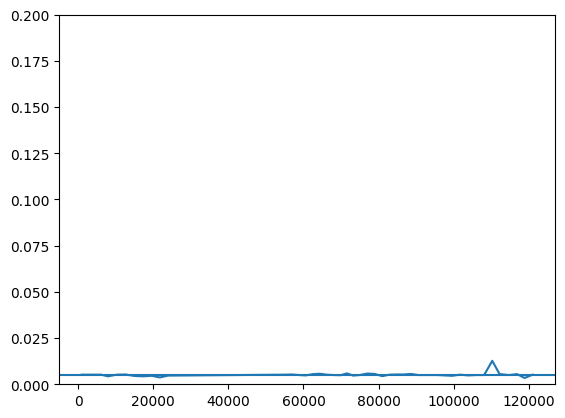

In [6]:
plt.figure()
plt.plot(df_iniciales['force_real'])

plt.axhline(0.005)

plt.ylim(0,0.2)

In [9]:
%matplotlib qt
plt.figure(figsize=(12,6))
plt.plot(df_datos['timestamp_corr'], df_datos['force'], label="Fuerza corregida")

for t in timestamps_ini_corr:
    plt.axvline(t, color='red', alpha=0.6)

for t in timestamps_final_corr:
    plt.axvline(t, color='green', alpha=0.6)

# puntos exactos en las marcas de inicio
plt.scatter(timestamps_ini_corr, df_iniciales['force_real'],
            s=60, marker='o', edgecolor='black', label="Marca Inicial")

plt.axhline(0.2)
plt.axhline(0.005,color='black')
plt.xlabel("Tiempo corregido (millis)")
plt.ylabel("Fuerza (kg)")
plt.title("Fuerza con marcas corregidas")

plt.show()
